In [ ]:
#EDA PARA EL DATASET DEL ICFES

In [2]:
# Análisis Exploratorio y Validación

#Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Cargar el dataset
df = pd.read_csv("notas_icfes.csv")

# Vista rápida
df.head()


,PERIODO,ESTU_TIPODOCUMENTO,ESTU_CONSECUTIVO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CALENDARIO,COLE_CARACTER,COLE_COD_DANE_ESTABLECIMIENTO,COLE_COD_DANE_SEDE,COLE_COD_DEPTO_UBICACION,...,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL,AÑO,SESION
0,20162,TI,SB11201620084846,URBANO,N,A,TECNICO/ACADEMICO,176001000000,176001000000,76,...,SI,A2,59,57,46,57,57,276.0,2016.0,2.0
1,20142,TI,SB11201420437853,URBANO,N,A,ACADEMICO,176895000000,176895000000,76,...,SI,A-,48,45,29,45,38,205.0,2014.0,2.0
2,20111,TI,SB11201110031540,URBANO,N,B,ACADEMICO,376001000000,376001000000,76,...,SI,B1,80,60,75,71,68,354.0,2011.0,1.0
3,20122,TI,SB11201220211394,URBANO,N,A,TECNICO/ACADEMICO,376001000000,376001000000,76,...,SI,A-,40,49,44,45,47,225.0,2012.0,2.0
4,20132,TI,SB11201320371098,URBANO,N,A,TECNICO/ACADEMICO,176001000000,176001000000,76,...,SI,A-,37,46,44,41,43,211.0,2013.0,2.0


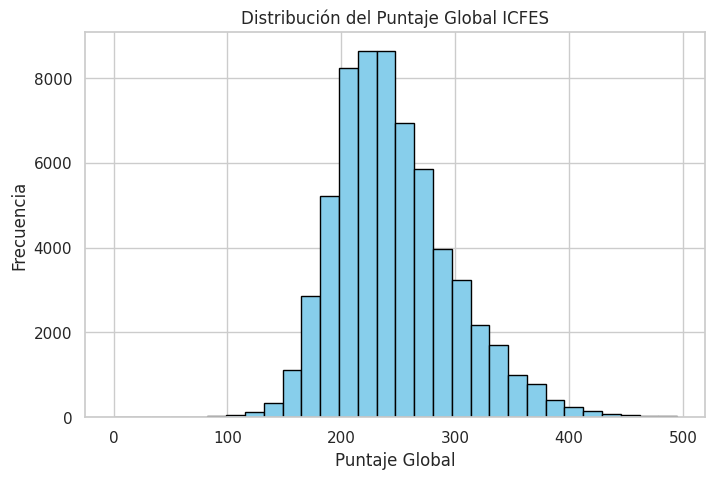

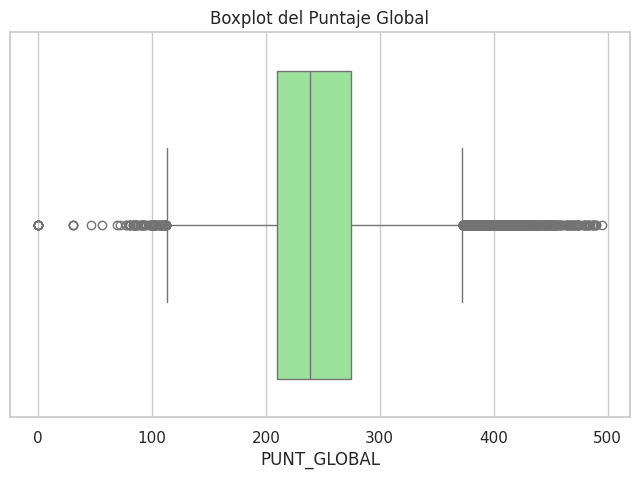

In [3]:
# Estadísticas descriptivas del puntaje global
df['PUNT_GLOBAL'].describe()

# Histograma de la distribución
plt.hist(df['PUNT_GLOBAL'], bins=30, color="skyblue", edgecolor="black")
plt.title("Distribución del Puntaje Global ICFES")
plt.xlabel("Puntaje Global")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot para detectar outliers
sns.boxplot(x=df['PUNT_GLOBAL'], color="lightgreen")
plt.title("Boxplot del Puntaje Global")
plt.show()



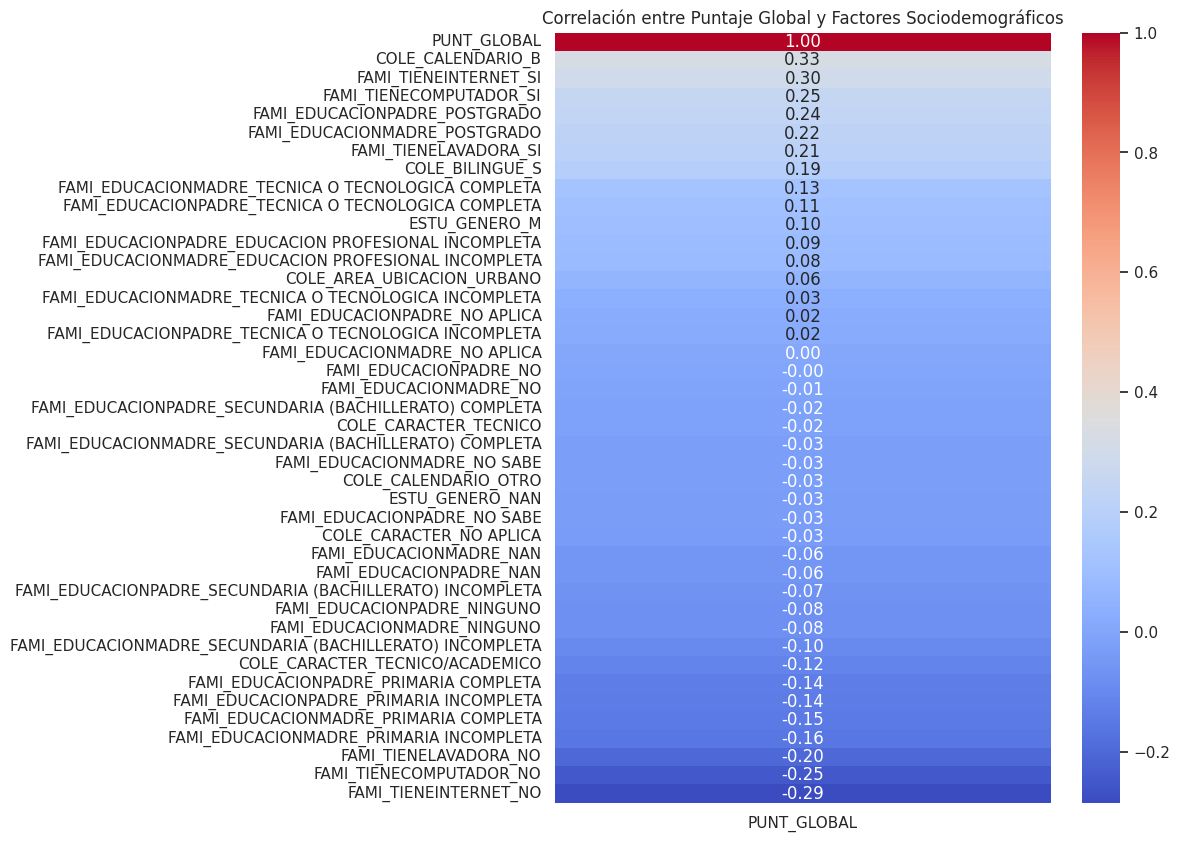

In [5]:
# Variables sociodemográficas significativas
socio_cols = [
    'FAMI_TIENEINTERNET','FAMI_TIENECOMPUTADOR','FAMI_TIENELAVADORA',
    'FAMI_EDUCACIONPADRE','FAMI_EDUCACIONMADRE',
    'COLE_AREA_UBICACION','COLE_BILINGUE','COLE_CALENDARIO','COLE_CARACTER',
    'ESTU_GENERO'
]

# Crear DataFrame con PUNT_GLOBAL + sociodemográficas
df_socio = df[['PUNT_GLOBAL'] + socio_cols].copy()

# Codificar variables categóricas
df_encoded = pd.get_dummies(df_socio, drop_first=True)

# Calcular correlación
corr_matrix = df_encoded.corr()

# Visualizar correlaciones con PUNT_GLOBAL
plt.figure(figsize=(8,10))
sns.heatmap(corr_matrix[['PUNT_GLOBAL']].sort_values(by='PUNT_GLOBAL', ascending=False),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre Puntaje Global y Factores Sociodemográficos")
plt.show()


In [ ]:
# Revisar valores únicos en variables sensibles
print("Valores únicos en ubicación:", df['COLE_AREA_UBICACION'].unique())
print("Valores únicos en bilingüe:", df['COLE_BILINGUE'].unique())
print("Valores únicos en calendario:", df['COLE_CALENDARIO'].unique())

# Checklist ético:
# - Evitar conclusiones que estigmaticen colegios rurales/urbanos.
# - No usar lenguaje que sugiera inferioridad/superioridad.
# - Documentar hallazgos como correlaciones estadísticas, no juicios de valor.



Valores únicos en ubicación: ['URBANO' 'RURAL']
Valores únicos en bilingüe: ['N' 'S']
Valores únicos en calendario: ['A' 'B' 'OTRO']


In [6]:
# Revisar rango de años en el dataset
print("Año mínimo en el dataset:", df['AÑO'].min())
print("Año máximo en el dataset:", df['AÑO'].max())


Año mínimo en el dataset: 2010.0
Año máximo en el dataset: 2022.0
